In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import sys
sys.path.insert(1, '../')
sys.path.insert(1, 'geom_files/')
sys.path.insert(1, 'gnn_files/')

from Harmonic_degree import *
from HOLR_functions import *

Required import functions

In [2]:
def import_network_data(f):
    edges = []
    for i, line in enumerate(f):
        if i == 0:
            continue  # Skip the first line
        words = line.split()
        edges.append((words[0], words[1]))
    
    f.close()
    
    # Create an undirected graph from edge list
    G = nx.Graph()
    G.add_edges_from(edges)
    
    # Remove self-loops
    G.remove_edges_from(nx.selfloop_edges(G))
    
    # Extract the largest connected component
    largest_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest_cc).copy()
    
    # Relabel nodes in ascending order starting from 0
    G = nx.convert_node_labels_to_integers(G, ordering="sorted")
    
    return G


In [3]:
# Colors
measure_colors = ["salmon","lightseagreen","goldenrod"]

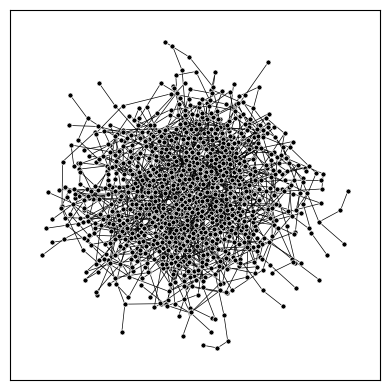

In [ ]:
# Load networks
# Road
f_road=open(r"out.subelj_euroroad_euroroad")
Ag=import_network_data(f_road)
f,ax=plt.subplots(1,1,figsize=(4,4))
layout = nx.spring_layout(Ag, iterations=100)
nodes = nx.draw_networkx_nodes(Ag,pos=layout,node_size = 13, node_color = "k")
ax.collections[0].set_linewidth(0.5) 
ax.collections[0].set_edgecolor("#FFFFFF") 
nx.draw_networkx_edges(Ag,pos=layout, width = 0.5)
plt.tight_layout()


In [7]:
print(len(Ag.nodes()))

1039


In [8]:
results_euroroad = {}
results_euroroad["Graph"] = Ag
results_euroroad["length original Graph"] = len(Ag.nodes())

# Laplacian renormalization

### Load pre-computed results

In [9]:
results_path = "../pre_computed_measures/Euroroad_results.pkl"
with open(results_path, "rb") as f:
    results = pickle.load(f)

M_DEG_H_l = results['Laplacian Harmonic Modified']
M_DEG_CF_l = results['Laplacian Conformal Modified']
STD_H_l = results['Laplacian H Dev']
GRAPHS_l = results['Laplacian Graph list']

### **or** compute measures from scratch

In [ ]:
# Laplacian
L0=nx.laplacian_matrix(Ag, nodelist = Ag.nodes()).todense()
e,ev=np.linalg.eigh(L0)

# Compute Harmonic Curves
GRAPHS_l, DEG_H_L, M_DEG_H_l, STD_H_l, AV_H_l, STD_V_H_l, NOT_H_l, DEG_CG_l, M_DEG_CF_l, STD_CF_l, AV_CF_l, STD_V_CF_l, NOT_CF_l, gV_l, t_h_l = H_CF_curves(Ag,L0,100, pow(10,-4))

### Plotting

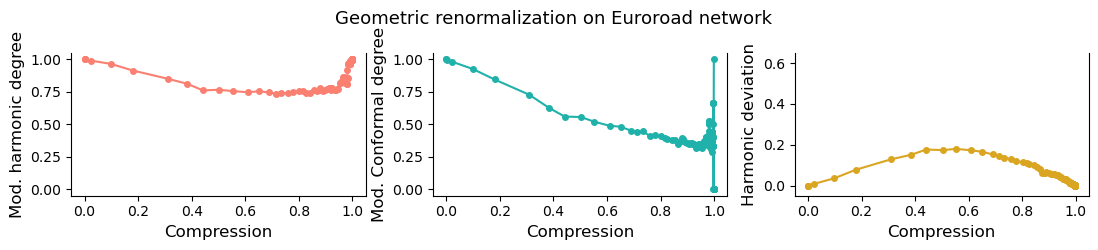

In [10]:
laplacian_compression = 1 - np.array([len(g) for g in GRAPHS_l])/len(Ag.nodes())

f = plt.figure(figsize=(11,2.5))
ax = plt.subplot(1,3,1)
ax.plot(laplacian_compression,M_DEG_H_l,'-o',color=measure_colors[0],markersize=4)
ax.set_xlabel("Compression")
ax.set_ylabel("Mod. harmonic degree")
ax.set_ylim([-0.05,1.05])
plt.gca().spines['top'].set_visible(False)

ax = plt.subplot(1,3,2)
ax.plot(laplacian_compression,M_DEG_CF_l,'-o',color=measure_colors[1],markersize=4)
ax.set_xlabel("Compression")
ax.set_ylabel("Mod. Conformal degree")
ax.set_ylim([-0.05,1.05])
plt.gca().spines['top'].set_visible(False)

ax = plt.subplot(1,3,3)
ax.plot(laplacian_compression,STD_H_l,'-o',color=measure_colors[2],markersize=4)
ax.set_xlabel("Compression")
ax.set_ylabel("Harmonic deviation")
ax.set_ylim([-0.05,0.65])
plt.gca().spines['top'].set_visible(False)

plt.suptitle("Geometric renormalization on Euroroad network")
plt.tight_layout()


## Example renormalization

In [12]:
# Visualization
t=4
L0=nx.laplacian_matrix(Ag, nodelist = Ag.nodes()).todense()
G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv = renorm_graph_harmonic(Ag,t,L0, pow(10,-4))
Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
G, colors_d, sing_col = renorm_graph_plot(Ag,t,L0)
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
lay2=nx.spring_layout(G,iterations=100)

       H   Mod. H   Std. H       CF  Mod. CF  Std. CF
0.757459 0.735463 0.102946 0.059673 0.372727 0.854439


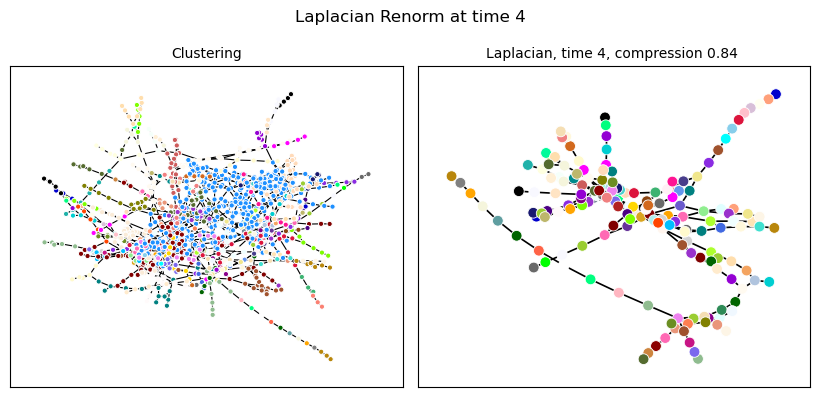

In [13]:
f,ax = plt.subplots(1,2,figsize = (8.3,4))

ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 14)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 0.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.7) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering", fontsize=10)

nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 60)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.2)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
#ax[1].set_title(f"Coarse graining at time {t}", fontsize=25)
ax[1].set_title(f"Laplacian, time {t}, compression {1 - len(G.nodes)/len(Ag.nodes):.2} ", fontsize=10)
f.suptitle(f"Laplacian Renorm at time {t}", fontsize=12) 
plt.tight_layout()
print(df.to_string(index=False))

# Geometric 

### Load pre-computed results

In [14]:
results_path = "../pre_computed_measures/Euroroad_results.pkl"
with open(results_path, "rb") as f:
    results = pickle.load(f)

M_DEG_H_g = results['Geometric Harmonic Modified']
M_DEG_CF_g = results['Geometric Conformal Modified']
STD_H_g = results['Geometric H Dev']
GRAPHS_g = results['Geometric Graph list']
lengths_g = np.arange(1,len(GRAPHS_g)+1)

### **or** compute measures from scratch

In [21]:
def read_supernode_file(filename):
    """ Reads a supernode assignment file and returns a dictionary mapping nodes to supernodes. """
    mapping = {}
    with open(filename, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                node, supernode = map(int, parts)
                mapping[node] = supernode
    return mapping

def build_cluster_hierarchy(layer_files):
    """ Constructs a hierarchical mapping from original nodes to supernodes across layers. """
    clusters = {}
    
    # Read the first layer mapping directly
    clusters[1] = read_supernode_file(layer_files[0])
    
    # Process subsequent layers
    for i in range(1, len(layer_files)):
        layer_supernodes = read_supernode_file(layer_files[i])
        previous_layer = clusters[i].copy()
        
        # Map original nodes to their new supernodes through the hierarchy
        clusters[i+1] = {}
        for node, prev_supernode in previous_layer.items():
            if prev_supernode in layer_supernodes:
                clusters[i+1][node] = layer_supernodes[prev_supernode]
            else:
                clusters[i+1][node] = prev_supernode  # If no new assignment, keep the old one
    
    return clusters


In [22]:
Road = Ag
mapping = {node: idx for idx, node in enumerate(sorted(Road.nodes()))}
Road = nx.relabel_nodes(Road, mapping)
print(len(Road.nodes()))

1039


In [23]:
# First step, from the network, create the edge file
output_file = "E-road.edge"  # Output file
nx.write_edgelist(Road,output_file, delimiter=" ", data=False)

now give the edge data to mercator and perform the embedding, thus obtaining the inf_coord and inf_log files

In [25]:
# File paths
coord_file = "geom_files/Embed_e_road.inf_coord"
new_coord_file = "geom_files/Embed_e_road_coordinates.txt"
new_edge_file = "geom_files/Embed_e_road_edgelist.txt"
param_file = "geom_files/Embed_e_road_parameters.txt"
# Step 1: Extract network parameters
N, beta, mu = None, None, None
coord = []
with open(coord_file, "r") as infile:
    for line in infile:
        line = line.strip()
        if "- nb. vertices:" in line:
            N = line.split(":")[1].strip()
        elif "- beta:" in line:
            beta = line.split(":")[1].strip()
        elif "- mu:" in line:
            mu = line.split(":")[1].strip()
        elif not line.startswith("#") and line:  # Read node data, ignore comments/empty lines
            values = line.split()
            if len(values) >= 3:
                coord.append((values[0], values[1], float(values[2])))  # (node, kappa, theta)
# Step 2: Write extracted parameters to a new file
with open(param_file, "w") as outfile:
    outfile.write("# N        beta             mu\n")  # Header line
    outfile.write(f"{N:<10} {beta:<16} {mu:<10}\n")
# Step 3: Sort nodes by theta
coord_sorted = sorted(coord, key=lambda x: x[2])
# Step 4: Create relabeling map {old_id: new_id}
node_map = {old_id: new_id for new_id, (old_id, _, _) in enumerate(coord_sorted)}
# Step 5: Write new coordinates file with updated labels
with open(new_coord_file, "w") as outfile:
    for new_id, (old_id, kappa, theta) in enumerate(coord_sorted):
        outfile.write(f"{new_id} {kappa} {theta}\n")
node_map_2 = {int(key): value for key, value in node_map.items()}
# Step 6: Relabel the existing tort network
# ATTENZIONE QUI A CAMBIARE LE COSE
Road = nx.relabel_nodes(Road, node_map_2)
# Step 7: Write the new edgelist with updated labels
with open(new_edge_file, "w") as outfile:
    for u, v in Road.edges():
        outfile.write(f"{u} {v}\n")
print("Processing complete. Files saved successfully.")

Processing complete. Files saved successfully.


Now give the files to the Renormalization_Binarized code and collect the outputs. We use the super node assignments

In [29]:
# Building the clusters we need to give to our method
layer_files = [f"geom_files/Geo_renorm_files/Renorm_e_road_output_RG_layer_{i}_supernode.txt" for i in range(1,12)]

clusters_g = build_cluster_hierarchy(layer_files)

In [30]:
GRAPHS_g = []
HDS_g = []
for i in range(1,len(clusters_g)+1):
    cl_g = clusters_g[i]
    G_g, deg_h_g, m_deg_h_g, std_h_g, av_h_g, std_v_h_g, Not_h_g, deg_cf_g, m_deg_cf_g, std_cf_g, av_cf_g, std_v_cf_g, Not_cf_g= H_CF_cluster(Road,cl_g)
    Values_g = [deg_h_g, m_deg_h_g, std_h_g, deg_cf_g, m_deg_cf_g, std_cf_g]
    HDS_g.append(Values_g)
    GRAPHS_g.append(G_g)

HDS_g=np.array(HDS_g)
DEG_H_g =HDS_g[:,0]
M_DEG_H_g = HDS_g[:,1]
DEG_CF_g = HDS_g[:,3]
M_DEG_CF_g = HDS_g[:,4]
STD_H_g = HDS_g[:,2]
STD_CF_g = HDS_g[:,5]
lengths_g = np.arange(1,HDS_g.shape[0]+1)

### Plot

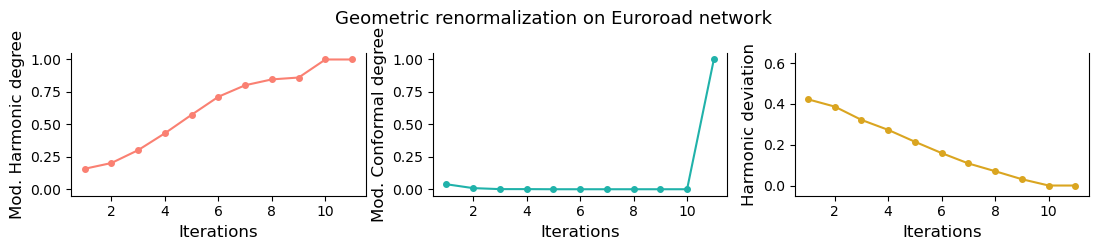

In [15]:
f = plt.figure(figsize=(11,2.5))
ax = plt.subplot(1,3,1)
ax.plot(lengths_g,M_DEG_H_g,'-o',color=measure_colors[0],markersize=4)
ax.set_xlabel("Iterations")
ax.set_ylabel("Mod. Harmonic degree")
ax.set_ylim([-0.05,1.05])
plt.gca().spines['top'].set_visible(False)

ax = plt.subplot(1,3,2)
ax.plot(lengths_g,M_DEG_CF_g,'-o',color=measure_colors[1],markersize=4)
ax.set_xlabel("Iterations")
ax.set_ylabel("Mod. Conformal degree")
ax.set_ylim([-0.05,1.05])
plt.gca().spines['top'].set_visible(False)

ax = plt.subplot(1,3,3)
ax.plot(lengths_g,STD_H_g,'-o',color=measure_colors[2],markersize=4)
ax.set_xlabel("Iterations")
ax.set_ylabel("Harmonic deviation")
ax.set_ylim([-0.05,0.65])
plt.gca().spines['top'].set_visible(False)

plt.suptitle("Geometric renormalization on Euroroad network")
plt.tight_layout()

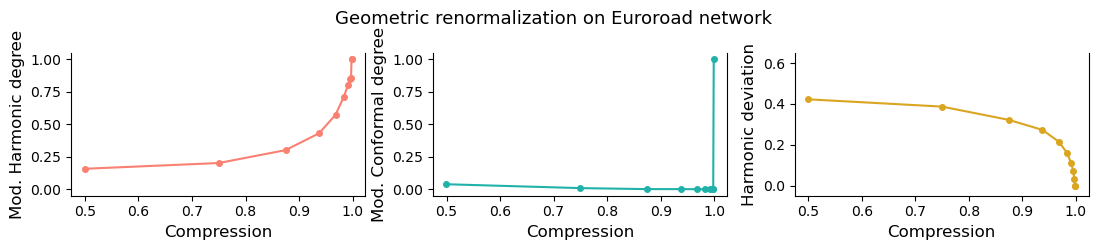

In [16]:
geometric_compression = 1 - np.array([len(g) for g in GRAPHS_g])/len(Ag.nodes())

f = plt.figure(figsize=(11,2.5))
ax = plt.subplot(1,3,1)
ax.plot(geometric_compression,M_DEG_H_g,'-o',color=measure_colors[0],markersize=4)
ax.set_xlabel("Compression")
ax.set_ylabel("Mod. Harmonic degree")
ax.set_ylim([-0.05,1.05])
plt.gca().spines['top'].set_visible(False)

ax = plt.subplot(1,3,2)
ax.plot(geometric_compression,M_DEG_CF_g,'-o',color=measure_colors[1],markersize=4)
ax.set_xlabel("Compression")
ax.set_ylabel("Mod. Conformal degree")
ax.set_ylim([-0.05,1.05])
plt.gca().spines['top'].set_visible(False)

ax = plt.subplot(1,3,3)
ax.plot(geometric_compression,STD_H_g,'-o',color=measure_colors[2],markersize=4)
ax.set_xlabel("Compression")
ax.set_ylabel("Harmonic deviation")
ax.set_ylim([-0.05,0.65])
plt.gca().spines['top'].set_visible(False)

plt.suptitle("Geometric renormalization on Euroroad network")
plt.tight_layout()


## Example Geometric

In [31]:
iteration = 6
cl = clusters_g[iteration]
G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf= H_CF_cluster(Road,cl)
Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
# Plotting
G, colors_d, sing_col = clust_plot(Road,cl)
# this should follow the natural order, so that the plot is correct
colors = [colors_d[n] for n in Road.nodes()]
layout = nx.spring_layout(Road, iterations=100)
lay2=nx.spring_layout(G,iterations=70)


       H   Mod. H   Std. H  CF  Mod. CF  Std. CF
0.715111 0.712929 0.158936 0.0      0.0 1.313594


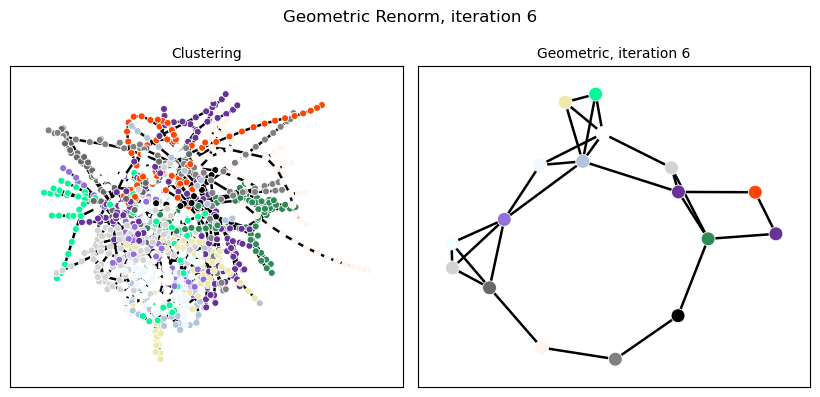

In [32]:
f,ax = plt.subplots(1,2,figsize = (8.3,4))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Road,ax=ax[0],pos=layout,node_color=colors,node_size = 25)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Road,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF")
ax[0].set_title(f"Clustering", fontsize = 10)
nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 100)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Geometric, iteration {iteration}", fontsize = 10)
f.suptitle(f"Geometric Renorm, iteration {iteration}", fontsize=12)
plt.tight_layout()
print(df.to_string(index=False))
#f.savefig(f"Euroroad_geom_it_{iteration}.pdf")

# GNN

### Load pre-computed results

In [39]:
results_path = "../pre_computed_measures/Euroroad_results.pkl"
with open(results_path, "rb") as f:
    results = pickle.load(f)

GNN_data = np.array(results['GNN DATA']).reshape(-1,6)
number_of_nodes = results['GNN realn number of nodes']

### *or* compute measures from scratch

In [35]:
g = Ag
mapping = {node: idx for idx, node in enumerate(sorted(g.nodes()))}
g = nx.relabel_nodes(g, mapping)
print(len(g.nodes()))

1039


In [36]:
from tqdm import *
import random
import torch
import torch_geometric
sys.path.insert(1, '../gnn_files/')
from model import Encoder,WeightSumDecoder
from data import get_feature,get_zt_ts
from utils import mins_cross_entropy,shuffle_rows
import pandas as pd
import pickle

/Users/marconurisso/miniconda3/envs/generalization/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [37]:
s = 2050
torch.manual_seed(s)
np.random.seed(s)
random.seed(s)
#device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device = 'cpu'

In [ ]:
# we extract features from data
ts = np.logspace(-2,1.5,15,base=10).tolist()
X = get_feature(g).float().to(device)
adj = torch.from_numpy(nx.to_numpy_array(g)).to(device)
y = get_zt_ts(adj,ts).real.float().to(device)
edge_index = torch_geometric.utils.dense_to_sparse(adj)[0].to(device)

L = len(g.nodes())
result = []
value = L // 2
# Step 1: Build the original list (halvings)
base = []
while value >= 1:
    base.append(value)
    value //= 2
# Step 2: Insert midpoints
lengths = []
for i in range(len(base) - 1):
    lengths.append(base[i])
    midpoint = (base[i] + base[i + 1]) // 2
    lengths.append(midpoint)
lengths.append(base[-1])  # Add the last element
# Step 3: Add L, 7/8*L, 3/4*L, 5/8*L
extra = [L, int(7 * L / 8), int(3 * L / 4), int(5 * L / 8)]
# Step 4: Combine and deduplicate
full_list = list(set(lengths + extra))
full_list.sort(reverse=True)  # descending order if you prefer
lengths = full_list
print(lengths)

CL =[]
LOSS =[]
for l in lengths:
    s = 2050
    torch.manual_seed(s)
    np.random.seed(s)
    random.seed(s)
    #device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    device = 'cpu'
    # Define model and optimizer
    macro_node = l
    encoder = Encoder(input_dim =5, hidden_dim = 64, output_dim = macro_node, n_layers = 2).to(device)
    decoder = WeightSumDecoder(macro_node)
    op = torch.optim.Adam(encoder.parameters(),lr=0.0001)
    # record the loss
    lss_train = []
    lss_ce = []
    for e in tqdm(range(2000)):
        # Partition function evaluation
        group = encoder(X,edge_index)
        new_p = decoder(group,adj.float())
        yhat = get_zt_ts(new_p,ts)
        l0 = torch.mean(torch.abs(y-yhat))
        # Cross Entropy Loss exists to make nodes as seperate as possible, it will be helpful for training in most cases
        sgroup = shuffle_rows(group)
        l1 = mins_cross_entropy(sgroup,group)
        loss= l0+l1*0.005 # this weight should not be too large, you can try by yourself
        # backpropagation and gradient decent
        op.zero_grad()
        loss.backward()
        op.step()
        # recording
        lss_train.append(l0.item())
        lss_ce.append(l1.item())
    final_loss = lss_train[-1]
    a = group.cpu().detach().t().numpy()


    ## IMPORTANT 
    # Number of samples
    N = 50
    # To store all the cluster dictionaries
    cluster_samples = []
    # For N repetitions
    for _ in range(N):
        clusters = {}
        for col_idx in range(a.shape[1]):
            # The probability distribution for this column
            probs = a[:, col_idx]
            # Possible row indices
            row_indices = np.arange(a.shape[0])
            # Sample one row index according to the column probabilities
            sampled_row = np.random.choice(row_indices, p=probs)
            clusters[col_idx] = sampled_row
        cluster_samples.append(clusters)
    CL.append(cluster_samples)
    LOSS.append(final_loss)

In [ ]:
V = []
Graphs_gnn = []
for cluster_samples in CL:
    HDS = []
    for clusters in cluster_samples:
        G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf= H_CF_cluster(g,clusters)
        Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
        HDS.append(Values)
        Graphs_gnn.append(G)
    HDS=np.array(HDS)
    V.append(HDS)

# Compute statistics
L = len(V)
means = np.zeros((6, L))
q25s = np.zeros((6, L))
q75s = np.zeros((6, L))
for i, mat in enumerate(V):  # mat is (N, 6)
    means[:, i] = np.mean(mat, axis=0)
    q25s[:, i] = np.percentile(mat, 25, axis=0)
    q75s[:, i] = np.percentile(mat, 75, axis=0)

### Plot

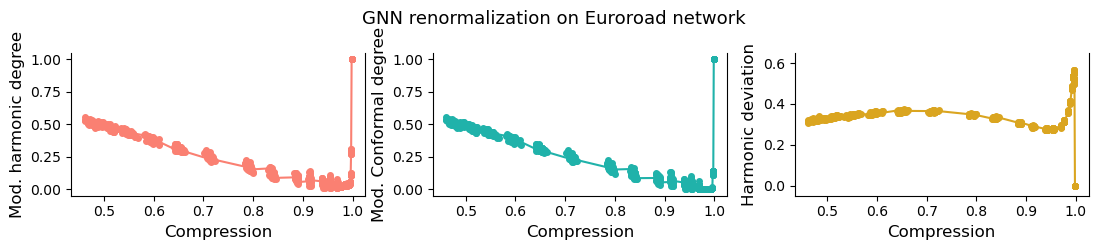

In [40]:
gnn_compression = 1 - np.array(number_of_nodes)/len(Ag.nodes())

m_h_deg_id = 1
m_cf_deg_id = 4
std_h_id = 2

f = plt.figure(figsize=(11,2.5))
ax = plt.subplot(1,3,1)
ax.plot(gnn_compression,GNN_data[:,m_h_deg_id],'-o',color=measure_colors[0],markersize=4)
ax.set_xlabel("Compression")
ax.set_ylabel("Mod. harmonic degree")
ax.set_ylim([-0.05,1.05])
plt.gca().spines['top'].set_visible(False)

ax = plt.subplot(1,3,2)
ax.plot(gnn_compression,GNN_data[:,m_cf_deg_id],'-o',color=measure_colors[1],markersize=4)
ax.set_xlabel("Compression")
ax.set_ylabel("Mod. Conformal degree")
ax.set_ylim([-0.05,1.05])
plt.gca().spines['top'].set_visible(False)

ax = plt.subplot(1,3,3)
ax.plot(gnn_compression,GNN_data[:,std_h_id],'-o',color=measure_colors[2],markersize=4)
ax.set_xlabel("Compression")
ax.set_ylabel("Harmonic deviation")
ax.set_ylim([-0.05,0.65])
plt.gca().spines['top'].set_visible(False)

plt.suptitle("GNN renormalization on Euroroad network")
plt.tight_layout()


## Example GNN, one sample

In [14]:
# PUT THE SEED EVERYTIME
s = 2050
torch.manual_seed(s)
np.random.seed(s)
random.seed(s)
#device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device = 'cpu'


# we extract features from data
ts = np.logspace(-2,1.5,15,base=10).tolist()
X = get_feature(g).float().to(device)
adj = torch.from_numpy(nx.to_numpy_array(g)).to(device)
y = get_zt_ts(adj,ts).real.float().to(device)
edge_index = torch_geometric.utils.dense_to_sparse(adj)[0].to(device)


# Define model and optimizer
macro_node = 50
encoder = Encoder(input_dim =5, hidden_dim = 64, output_dim = macro_node, n_layers = 1).to(device)
decoder = WeightSumDecoder(macro_node)
op = torch.optim.Adam(encoder.parameters(),lr=0.0001)

# record the loss
lss_train = []
lss_ce = []
for e in tqdm(range(2000)):
    # Partition function evaluation
    group = encoder(X,edge_index)
    new_p = decoder(group,adj.float())
    yhat = get_zt_ts(new_p,ts)
    l0 = torch.mean(torch.abs(y-yhat))
    
    # Cross Entropy Loss exists to make nodes as seperate as possible, it will be helpful for training in most cases
    sgroup = shuffle_rows(group)
    l1 = mins_cross_entropy(sgroup,group)
    
    loss= l0+l1*0.005 # this weight should not be too large, you can try by yourself
    
    # backpropagation and gradient decent
    op.zero_grad()
    loss.backward()
    op.step()
    
    # recording
    lss_train.append(l0.item())
    lss_ce.append(l1.item())

a = group.cpu().detach().t().numpy()

# Take one sample


clusters = {}
for col_idx in range(a.shape[1]):
        # The probability distribution for this column
    probs = a[:, col_idx]
        # Possible row indices
    row_indices = np.arange(a.shape[0])
        # Sample one row index according to the column probabilities
    sampled_row = np.random.choice(row_indices, p=probs)
    clusters[col_idx] = sampled_row

# Example output
#print(cluster_samples[1])

100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:18<00:00, 105.78it/s]


     H   Mod. H  Var. H       CF  Mod. CF  Var. CF
0.0077 0.023723 0.27692 0.000962 0.020408 0.337045


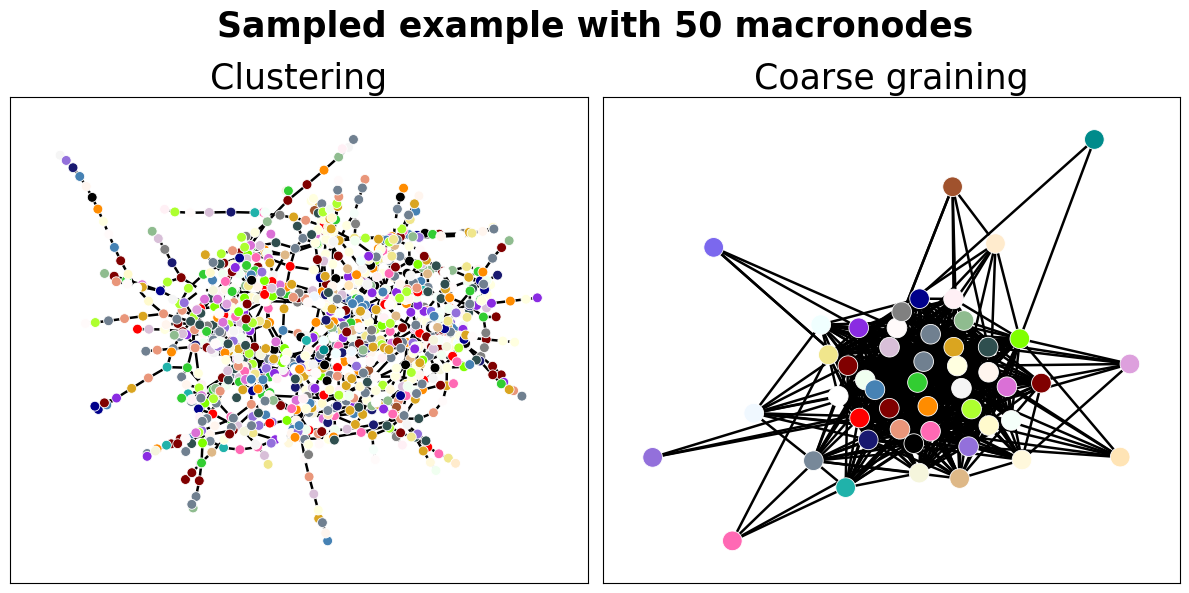

In [16]:
G, deg_h, M_deg_h, var_h, av_h, var_v_h, Not_h, deg_cf, M_deg_cf, var_cf, av_cf, var_v_cf, Not_cf= H_CF_cluster(g,clusters)
Values = [deg_h, M_deg_h, var_h, deg_cf, M_deg_cf, var_cf]
Labels = ["H", "Mod. H", "Var. H", "CF", "Mod. CF", "Var. CF"]
df = pd.DataFrame([Values], columns = Labels)
# Plotting
G, colors_d, sing_col = clust_plot(g,clusters)
# this should follow the natural order, so that the plot is correct
colors = [colors_d[n] for n in g.nodes()]
layout = nx.spring_layout(g, iterations=100)
lay2=nx.spring_layout(G,iterations=70)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(g,ax=ax[0],pos=layout,node_color=colors,node_size = 50)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(g,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering", fontsize = 25)
nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 200)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining", fontsize = 25)
# Add a big title for the whole figure
f.suptitle(f"Sampled example with {macro_node} macronodes", fontsize=25, fontweight="bold")
plt.tight_layout()
print(df.to_string(index=False))

# All together

In [41]:
model_colors = ["goldenrod","salmon","lightseagreen"]

/var/folders/f6/5t2dxw1n72nf__cgdxs0x8m80000gn/T/ipykernel_2469/3420415848.py:40: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  plt.legend(["Laplacian","_nolegend_","Geometric","GNN"], loc='upper right', ncols = 3, bbox_to_anchor=(-0.1, 1.25), fontsize=12)


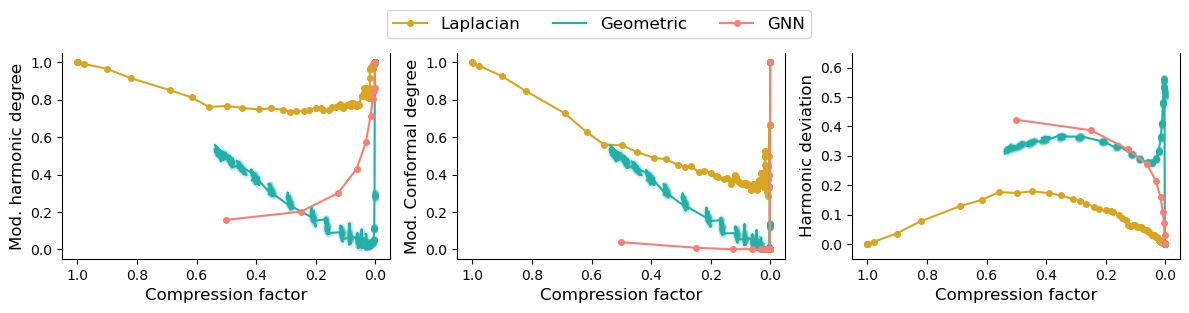

In [42]:
m_h_deg_id = 1
m_cf_deg_id = 4
std_h_id = 2

f = plt.figure(figsize=(12,2.8))
ax = plt.subplot(1,3,1)
ax.plot(1-laplacian_compression,M_DEG_H_l,'-o',color=model_colors[0],markersize=4)
ax.plot(1-gnn_compression,GNN_data[:,m_h_deg_id],'-o',color=model_colors[2],markersize=4, alpha = 0.05)
ax.plot(1-gnn_compression,GNN_data[:,m_h_deg_id],'-',color=model_colors[2])
ax.plot(1-geometric_compression,M_DEG_H_g,'-o',color=model_colors[1],markersize=4)
ax.set_xlabel("Compression factor")
ax.set_ylabel("Mod. harmonic degree")
ax.set_ylim([-0.05,1.05])
plt.gca().spines['top'].set_visible(False)
ax.invert_xaxis()

ax = plt.subplot(1,3,2)
ax.plot(1-laplacian_compression,M_DEG_CF_l,'-o',color=model_colors[0],markersize=4)
ax.plot(1-gnn_compression,GNN_data[:,m_cf_deg_id],'-o',color=model_colors[2],markersize=4, alpha = 0.05)
ax.plot(1-gnn_compression,GNN_data[:,m_cf_deg_id],'-',color=model_colors[2]),
ax.plot(1-geometric_compression,M_DEG_CF_g,'-o',color=model_colors[1],markersize=4)
ax.set_xlabel("Compression factor")
ax.set_ylabel("Mod. Conformal degree")
ax.set_ylim([-0.05,1.05])
plt.gca().spines['top'].set_visible(False)
ax.invert_xaxis()

ax = plt.subplot(1,3,3)
ax.plot(1-laplacian_compression,STD_H_l,'-o',color=model_colors[0],markersize=4)
ax.plot(1-gnn_compression,GNN_data[:,std_h_id],'-o',color=model_colors[2],markersize=4, alpha = 0.05)
ax.plot(1-gnn_compression,GNN_data[:,std_h_id],'-',color=model_colors[2])
ax.plot(1-geometric_compression,STD_H_g,'-o',color=model_colors[1],markersize=4)
ax.set_xlabel("Compression factor")
ax.set_ylabel("Harmonic deviation")
ax.set_ylim([-0.05,0.65])
plt.gca().spines['top'].set_visible(False) 
ax.invert_xaxis()

plt.tight_layout()
plt.legend(["Laplacian","_nolegend_","Geometric","GNN"], loc='upper right', ncols = 3, bbox_to_anchor=(-0.1, 1.25), fontsize=12)

plt.savefig("./Euroroad_comparison.pdf", bbox_inches='tight')

/var/folders/f6/5t2dxw1n72nf__cgdxs0x8m80000gn/T/ipykernel_2469/84915638.py:48: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  plt.legend(["Laplacian","_nolegend_","Geometric","GNN"], loc='upper right', ncols = 3, bbox_to_anchor=(-0.1, 1.25), fontsize=12)


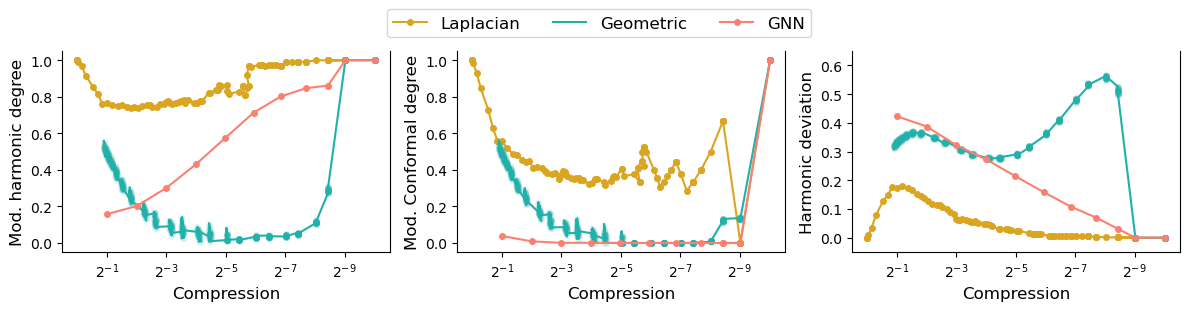

In [43]:
m_h_deg_id = 1
m_cf_deg_id = 4
std_h_id = 2

f = plt.figure(figsize=(12,2.8))
ax = plt.subplot(1,3,1)
ax.plot(1-laplacian_compression,M_DEG_H_l,'-o',color=model_colors[0],markersize=4)
ax.plot(1-gnn_compression,GNN_data[:,m_h_deg_id],'-o',color=model_colors[2],markersize=4, alpha = 0.05)
ax.plot(1-gnn_compression,GNN_data[:,m_h_deg_id],'-',color=model_colors[2])
ax.plot(1-geometric_compression,M_DEG_H_g,'-o',color=model_colors[1],markersize=4)


ax.set_xlabel("Compression")
ax.set_ylabel("Mod. harmonic degree")
ax.set_ylim([-0.05,1.05])
plt.gca().spines['top'].set_visible(False)
ax.set_xscale("log",base = 2)
ax.invert_xaxis()

ax = plt.subplot(1,3,2)
ax.plot(1-laplacian_compression,M_DEG_CF_l,'-o',color=model_colors[0],markersize=4)
ax.plot(1-gnn_compression,GNN_data[:,m_cf_deg_id],'-o',color=model_colors[2],markersize=4, alpha = 0.05)
ax.plot(1-gnn_compression,GNN_data[:,m_cf_deg_id],'-',color=model_colors[2]),
ax.plot(1-geometric_compression,M_DEG_CF_g,'-o',color=model_colors[1],markersize=4)

ax.set_xlabel("Compression")
ax.set_ylabel("Mod. Conformal degree")
ax.set_ylim([-0.05,1.05])
plt.gca().spines['top'].set_visible(False)
ax.set_xscale("log",base = 2)
ax.invert_xaxis()

ax = plt.subplot(1,3,3)
ax.plot(1-laplacian_compression,STD_H_l,'-o',color=model_colors[0],markersize=4)
ax.plot(1-gnn_compression,GNN_data[:,std_h_id],'-o',color=model_colors[2],markersize=4, alpha = 0.05)
ax.plot(1-gnn_compression,GNN_data[:,std_h_id],'-',color=model_colors[2])
ax.plot(1-geometric_compression,STD_H_g,'-o',color=model_colors[1],markersize=4)

ax.set_xlabel("Compression")
ax.set_ylabel("Harmonic deviation")
ax.set_ylim([-0.05,0.65])
plt.gca().spines['top'].set_visible(False)
ax.set_xscale("log",base = 2)
ax.invert_xaxis()


plt.tight_layout()
plt.legend(["Laplacian","_nolegend_","Geometric","GNN"], loc='upper right', ncols = 3, bbox_to_anchor=(-0.1, 1.25), fontsize=12)

#plt.savefig("./Euroroad_comparison.pdf", bbox_inches='tight')